In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("winequality-red.csv",sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df["quality"].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [5]:
features=df.drop("quality",axis=1)
target=df["quality"]

In [6]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,random_state=0,test_size=0.2,stratify=target)
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(1279, 11) (1279,)
(320, 11) (320,)


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [8]:
def mymodel(model):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    #Overfitting - underfitting check
    print(f"Training score : {model.score(xtrain,ytrain)}")
    print(f"Testing score : {model.score(xtest,ytest)}")
    c=pd.DataFrame(confusion_matrix(ypred,ytest),
                  index=[3,4,5,6,7,8],
                  columns=[3,4,5,6,7,8])
    print("Confusion Matrix : \n",c)
    print("Classification Report : \n",classification_report(ytest,ypred))
    return model

In [9]:
dt=mymodel(DecisionTreeClassifier())

Training score : 1.0
Testing score : 0.61875
Confusion Matrix : 
    3  4   5   6   7  8
3  0  0   0   0   0  0
4  0  0   5   1   0  0
5  2  5  95  26   4  0
6  0  6  29  82  15  1
7  0  0   6  16  21  2
8  0  0   1   3   0  0
Classification Report : 
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.72      0.70      0.71       136
           6       0.62      0.64      0.63       128
           7       0.47      0.53      0.49        40
           8       0.00      0.00      0.00         3

    accuracy                           0.62       320
   macro avg       0.30      0.31      0.31       320
weighted avg       0.61      0.62      0.61       320



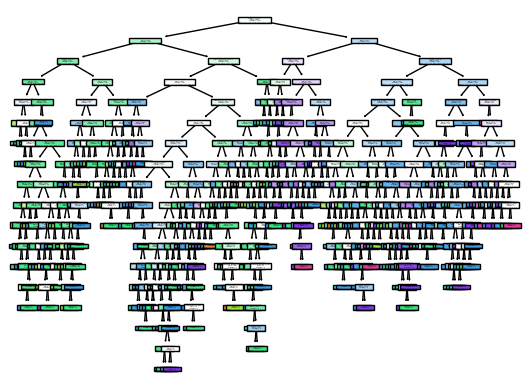

In [10]:
from sklearn import tree
tree.plot_tree(dt,feature_names=xtrain.columns,filled=True)
plt.show()

In [11]:
# hyperparameter tuning for pruning of decision tree

In [12]:
from sklearn.ensemble import RandomForestClassifier
rf=mymodel(RandomForestClassifier())

Training score : 1.0
Testing score : 0.70625
Confusion Matrix : 
    3  4    5   6   7  8
3  0  0    0   0   0  0
4  0  0    0   0   0  0
5  1  5  113  26   1  0
6  1  6   21  96  22  2
7  0  0    2   6  17  1
8  0  0    0   0   0  0
Classification Report : 
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.77      0.83      0.80       136
           6       0.65      0.75      0.70       128
           7       0.65      0.42      0.52        40
           8       0.00      0.00      0.00         3

    accuracy                           0.71       320
   macro avg       0.35      0.33      0.34       320
weighted avg       0.67      0.71      0.68       320



In [13]:
'''
parameters={
    "n_estimators":[80,120,200],
    "max_depth":list(range(2,5)), # 2,3,4
    "min_samples_split":list(range(2,5)), # 2,3,4
    "min_samples_leaf":list(range(3,9))  #3,4,5,6,7,8
}
'''

'\nparameters={\n    "n_estimators":[80,120,200],\n    "max_depth":list(range(2,5)), # 2,3,4\n    "min_samples_split":list(range(2,5)), # 2,3,4\n    "min_samples_leaf":list(range(3,9))  #3,4,5,6,7,8\n}\n'

In [14]:
'''
from sklearn.model_selection import GridSearchCV
clf=GridSearchCV(RandomForestClassifier(),parameters,verbose=2)
clf.fit(xtrain,ytrain)
'''

'\nfrom sklearn.model_selection import GridSearchCV\nclf=GridSearchCV(RandomForestClassifier(),parameters,verbose=2)\nclf.fit(xtrain,ytrain)\n'

In [15]:
#clf.best_estimator_

In [16]:
#ap=mymodel(clf.best_estimator_)

In [17]:
# balancing of target by over sampling

In [24]:
'''
# undersampling
df[df["quality"]==3].sample(5)
df[df["quality"]==4].sample(5)
'''

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1363,8.0,0.83,0.27,2.0,0.080,11.0,63.0,0.99652,3.29,0.48,9.8,4
937,12.0,0.63,0.50,1.4,0.071,6.0,26.0,0.99791,3.07,0.60,10.4,4
1482,7.2,0.58,0.54,2.1,0.114,3.0,9.0,0.99719,3.33,0.57,10.3,4
94,5.0,1.02,0.04,1.4,0.045,41.0,85.0,0.99380,3.75,0.48,10.5,4
573,10.5,0.59,0.49,2.1,0.070,14.0,47.0,0.99910,3.30,0.56,9.6,4


In [ ]:
#oversampling

In [25]:
df[df["quality"]==3].sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1505,6.7,0.760,0.02,1.8,0.078,6.0,12.0,0.99600,3.55,0.63,9.95,3
1374,6.8,0.815,0.00,1.2,0.267,16.0,29.0,0.99471,3.32,0.51,9.80,3
459,11.6,0.580,0.66,2.2,0.074,10.0,47.0,1.00080,3.25,0.57,9.00,3
832,10.4,0.440,0.42,1.5,0.145,34.0,48.0,0.99832,3.38,0.86,9.90,3
517,10.4,0.610,0.49,2.1,0.200,5.0,16.0,0.99940,3.16,0.63,8.40,3


In [ ]:
# Random Over Sampler and SMOTE (Synthetic Minority Oversampling Technique) 

In [26]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [27]:
from imblearn.over_sampling import RandomOverSampler
ros=RandomOverSampler(random_state=1)
xsample,ysample=ros.fit_resample(xtrain,ytrain)

In [28]:
ysample.value_counts()

quality
5    545
6    545
7    545
4    545
8    545
3    545
Name: count, dtype: int64

In [30]:
from sklearn.model_selection import GridSearchCV
parameters={
    "n_estimators":[80,120,200],
    "max_depth":list(range(2,4)), # 2,3,4
    "min_samples_split":list(range(2,4)), # 2,3,4
    "min_samples_leaf":list(range(3,4))  #3
}
clf=GridSearchCV(RandomForestClassifier(),parameters,verbose=2)
clf.fit(xsample,ysample)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.2s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=120; total time=   0.2s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=120; total time=   0.2s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=120; total time=   0.2s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=120; total time=   0.2s
[CV] END max_depth=2, min_samples_leaf=3, mi

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 3], 'min_samples_leaf': [3],
                         'min_samples_split': [2, 3],
                         'n_estimators': [80, 120, 200]},
             verbose=2)

In [31]:
def mymodel_sample(model):
    model.fit(xsample,ysample)
    ypred=model.predict(xtest)
    #Overfitting - underfitting check
    print(f"Training score : {model.score(xsample,ysample)}")
    print(f"Testing score : {model.score(xtest,ytest)}")
    c=pd.DataFrame(confusion_matrix(ypred,ytest),
                  index=[3,4,5,6,7,8],
                  columns=[3,4,5,6,7,8])
    print("Confusion Matrix : \n",c)
    print("Classification Report : \n",classification_report(ytest,ypred))
    return model

In [32]:
p=mymodel_sample(clf.best_estimator_)
p

Training score : 0.6253822629969419
Testing score : 0.384375
Confusion Matrix : 
    3  4   5   6   7  8
3  1  6  10   6   0  0
4  0  3  17   8   3  0
5  1  1  99  52   3  0
6  0  0   2   8   3  0
7  0  1   4  33  10  1
8  0  0   4  21  21  2
Classification Report : 
               precision    recall  f1-score   support

           3       0.04      0.50      0.08         2
           4       0.10      0.27      0.14        11
           5       0.63      0.73      0.68       136
           6       0.62      0.06      0.11       128
           7       0.20      0.25      0.22        40
           8       0.04      0.67      0.08         3

    accuracy                           0.38       320
   macro avg       0.27      0.41      0.22       320
weighted avg       0.55      0.38      0.37       320



RandomForestClassifier(max_depth=3, min_samples_leaf=3, min_samples_split=3,
                       n_estimators=120)

In [33]:
df["quality"].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [34]:
def multi_to_bin(c):
    if c<6:
        return 0
    else:
        return 1

In [45]:
df["quality_bin"]=df["quality"].apply(multi_to_bin)

In [48]:
features=df.drop(["quality_bin","quality"],axis=1)
target=df["quality_bin"]

In [49]:
xtrain,xtest,ytrain,ytest=train_test_split(features,target,random_state=0,test_size=0.2,stratify=target)
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(1279, 11) (1279,)
(320, 11) (320,)


In [50]:
def mymodel_bin(model):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    #Overfitting - underfitting check
    print(f"Training score : {model.score(xtrain,ytrain)}")
    print(f"Testing score : {model.score(xtest,ytest)}")
    c=pd.DataFrame(confusion_matrix(ypred,ytest),
                  index=[0,1],
                  columns=[0,1])
    print("Confusion Matrix : \n",c)
    print("Classification Report : \n",classification_report(ytest,ypred))
    return model

In [52]:
from sklearn.model_selection import GridSearchCV
clf=GridSearchCV(RandomForestClassifier(),parameters,verbose=2)
clf.fit(xtrain,ytrain)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=120; total time=   0.2s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=120; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=120; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=120; total time=   0.1s
[CV] END max_depth=2, min_samples_leaf=3, mi

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 3], 'min_samples_leaf': [3],
                         'min_samples_split': [2, 3],
                         'n_estimators': [80, 120, 200]},
             verbose=2)

In [53]:
f=mymodel_bin(clf.best_estimator_)

Training score : 0.7638780297107115
Testing score : 0.7625
Confusion Matrix : 
      0    1
0  113   40
1   36  131
Classification Report : 
               precision    recall  f1-score   support

           0       0.74      0.76      0.75       149
           1       0.78      0.77      0.78       171

    accuracy                           0.76       320
   macro avg       0.76      0.76      0.76       320
weighted avg       0.76      0.76      0.76       320

